In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/ASD_XAI_Project"
os.makedirs(PROJECT_DIR, exist_ok=True)
print("Project folder created:", PROJECT_DIR)

Project folder created: /content/drive/MyDrive/ASD_XAI_Project


In [ ]:
folders = [
    "dataset",
    "slices",
    "models",
    "results",
    "metadata"
]

for folder in folders:
    path = os.path.join(PROJECT_DIR, folder)
    os.makedirs(path, exist_ok=True)

print("Project folders created!")

Project folders created!


In [ ]:
!pip install -q nibabel

In [ ]:
import nibabel as nib

mri_path = "/content/drive/MyDrive/ASD_XAI_Project/dataset/mprage.nii.gz"

mri = nib.load(mri_path)

print("MRI loaded successfully!")
print("MRI shape:", mri.shape)

MRI loaded successfully!
MRI shape: (176, 256, 256)


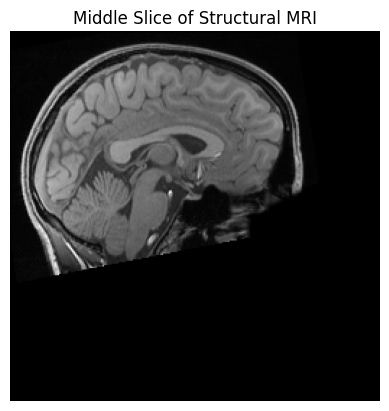

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mri_data = mri.get_fdata()

middle_slice = mri_data[mri_data.shape[0] // 2, :, :]

plt.imshow(middle_slice.T, cmap="gray", origin="lower")
plt.title("Middle Slice of Structural MRI")
plt.axis("off")
plt.show()

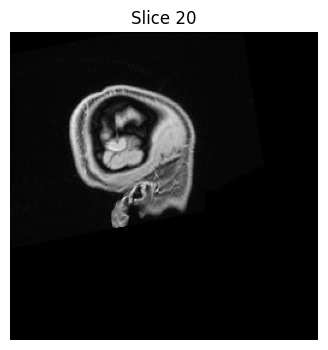

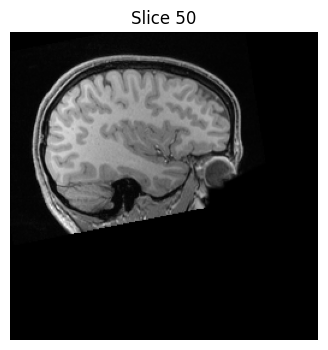

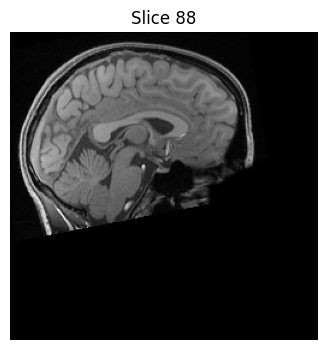

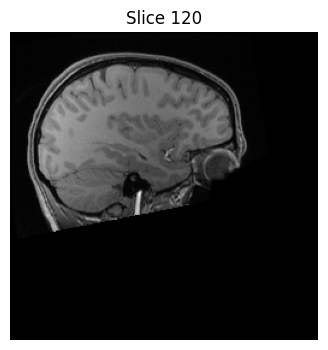

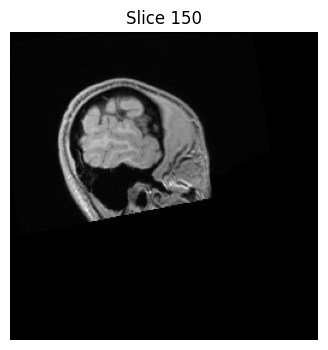

In [ ]:
slice_numbers = [20, 50, 88, 120, 150]

for slice_no in slice_numbers:
    plt.figure(figsize=(4, 4))
    plt.imshow(mri_data[slice_no, :, :].T, cmap="gray", origin="lower")
    plt.title(f"Slice {slice_no}")
    plt.axis("off")
    plt.show()

Load the 3D MRI using NiBabel.

Convert it to a NumPy array so Python can process the voxel values.

Normalize intensity values so different scans are on a more comparable scale.

Extract 2D slices from the chosen anatomical axis.

Remove/crop excessive empty background so the CNN focuses more on the brain region.

Resize each slice to EfficientNetB0’s expected image size, typically 224 × 224.

Convert grayscale → 3 channels because pretrained EfficientNetB0 expects RGB-like 3-channel input.

Save/prepare those processed slices for the later EfficientNet → SHAP/Permutation → Top-K selection stage.

In [ ]:
mri_min = mri_data.min()
mri_max = mri_data.max()

normalized_mri = (mri_data - mri_min) / (mri_max - mri_min)

print("Original range:", mri_min, "to", mri_max)
print("Normalized range:", normalized_mri.min(), "to", normalized_mri.max())

Original range: -4.0 to 1172.0
Normalized range: 0.0 to 1.0


Normalized value = x - minimum / maximum - minimum


In [ ]:
slice_index = normalized_mri.shape[0] // 2

slice_2d = normalized_mri[slice_index, :, :]

print("Selected slice:", slice_index)
print("Slice shape:", slice_2d.shape)
print("Slice intensity range:", slice_2d.min(), "to", slice_2d.max())

Selected slice: 88
Slice shape: (256, 256)
Slice intensity range: 0.003401360544217687 to 0.7236394557823129


In [ ]:
threshold = 0.01

brain_mask = slice_2d > threshold

print("Total pixels:", slice_2d.size)
print("Foreground pixels:", brain_mask.sum())
print("Background pixels:", slice_2d.size - brain_mask.sum())

Total pixels: 65536
Foreground pixels: 30483
Background pixels: 35053


In [ ]:
import pandas as pd

phenotypic_path = "/content/drive/MyDrive/ASD_XAI_Project/metadata/phenotypic_CALTECH.csv"

phenotypic_df = pd.read_csv(phenotypic_path)

print("Phenotypic file loaded successfully!")
print("Shape:", phenotypic_df.shape)

phenotypic_df.head()

Phenotypic file loaded successfully!
Shape: (38, 74)


,SITE_ID,SUB_ID,DX_GROUP,DSM_IV_TR,AGE_AT_SCAN,SEX,HANDEDNESS_CATEGORY,HANDEDNESS_SCORES,FIQ,VIQ,...,WISC_IV_BLK_DSN_SCALED,WISC_IV_PIC_CON_SCALED,WISC_IV_MATRIX_SCALED,WISC_IV_DIGIT_SPAN_SCALED,WISC_IV_LET_NUM_SCALED,WISC_IV_CODING_SCALED,WISC_IV_SYM_SCALED,EYE_STATUS_AT_SCAN,AGE_AT_MPRAGE,BMI
0,CALTECH,51456,1,4,55.4,1,R,NaN,126,118,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
1,CALTECH,51457,1,4,22.9,1,Ambi,NaN,107,119,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
2,CALTECH,51458,1,1,39.2,1,R,NaN,93,80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
3,CALTECH,51459,1,1,22.8,1,R,NaN,106,94,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN
4,CALTECH,51460,1,1,34.6,2,Ambi,NaN,133,135,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN


In [ ]:
labels_df = phenotypic_df[["SUB_ID", "DX_GROUP"]].copy()

print(labels_df)

print("\nDX_GROUP counts:")
print(labels_df["DX_GROUP"].value_counts())

    SUB_ID  DX_GROUP
0    51456         1
1    51457         1
2    51458         1
3    51459         1
4    51460         1
5    51461         1
6    51462         1
7    51463         1
8    51464         1
9    51465         1
10   51466         1
11   51467         1
12   51468         1
13   51469         1
14   51470         1
15   51471         1
16   51472         1
17   51473         1
18   51474         1
19   51475         2
20   51476         2
21   51477         2
22   51478         2
23   51479         2
24   51480         2
25   51481         2
26   51482         2
27   51483         2
28   51484         2
29   51485         2
30   51486         2
31   51487         2
32   51488         2
33   51489         2
34   51490         2
35   51491         2
36   51492         2
37   51493         2

DX_GROUP counts:
DX_GROUP
1    19
2    19
Name: count, dtype: int64


In [ ]:
import glob
import os

caltech_path = "/content/drive/MyDrive/ASD_XAI_Project/dataset/Caltech"

mri_files = glob.glob(
    os.path.join(caltech_path, "**", "anat_1", "mprage.nii.gz"),
    recursive=True
)

print("MRI files found:", len(mri_files))

for path in mri_files[:5]:
    print(path)

MRI files found: 38
/content/drive/MyDrive/ASD_XAI_Project/dataset/Caltech/Caltech/0051456/session_1/anat_1/mprage.nii.gz
/content/drive/MyDrive/ASD_XAI_Project/dataset/Caltech/Caltech/0051460/session_1/anat_1/mprage.nii.gz
/content/drive/MyDrive/ASD_XAI_Project/dataset/Caltech/Caltech/0051457/session_1/anat_1/mprage.nii.gz
/content/drive/MyDrive/ASD_XAI_Project/dataset/Caltech/Caltech/0051459/session_1/anat_1/mprage.nii.gz
/content/drive/MyDrive/ASD_XAI_Project/dataset/Caltech/Caltech/0051458/session_1/anat_1/mprage.nii.gz


In [ ]:
dataset_records = []

for mri_path in mri_files:
    # Example folder name: 0051456
    subject_folder = mri_path.split("/")[-4]

    # Convert 0051456 -> 51456
    subject_id = int(subject_folder)

    # Find diagnosis in phenotypic CSV
    row = labels_df[labels_df["SUB_ID"] == subject_id]

    if not row.empty:
        dx_group = int(row["DX_GROUP"].iloc[0])
        label = "ASD" if dx_group == 1 else "Control"

        dataset_records.append({
            "SUB_ID": subject_id,
            "MRI_PATH": mri_path,
            "DX_GROUP": dx_group,
            "LABEL": label
        })

dataset_df = pd.DataFrame(dataset_records)

dataset_df = dataset_df.sort_values("SUB_ID").reset_index(drop=True)

print("Subjects matched:", len(dataset_df))
print("\nLabel distribution:")
print(dataset_df["LABEL"].value_counts())

dataset_df.head()

Subjects matched: 38

Label distribution:
LABEL
ASD        19
Control    19
Name: count, dtype: int64


,SUB_ID,MRI_PATH,DX_GROUP,LABEL
0,51456,/content/drive/MyDrive/ASD_XAI_Project/dataset...,1,ASD
1,51457,/content/drive/MyDrive/ASD_XAI_Project/dataset...,1,ASD
2,51458,/content/drive/MyDrive/ASD_XAI_Project/dataset...,1,ASD
3,51459,/content/drive/MyDrive/ASD_XAI_Project/dataset...,1,ASD
4,51460,/content/drive/MyDrive/ASD_XAI_Project/dataset...,1,ASD


In [ ]:
orientations = set()

for path in dataset_df["MRI_PATH"]:
    img = nib.load(path)
    orientation = nib.aff2axcodes(img.affine)
    orientations.add(orientation)

print("Orientations found:", orientations)

Orientations found: {('L', 'A', 'S')}


-----------------------------------Batch Preprocessing------------------------------------------

In [ ]:
import os
import cv2
import numpy as np
import nibabel as nib

OUTPUT_DIR = "/content/drive/MyDrive/ASD_XAI_Project/slices"

os.makedirs(os.path.join(OUTPUT_DIR, "ASD"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "Control"), exist_ok=True)

MIN_FOREGROUND_RATIO = 0.10

processed_count = 0
saved_slices = 0

for _, row in dataset_df.iterrows():

    subject_id = row["SUB_ID"]
    label = row["LABEL"]
    mri_path = row["MRI_PATH"]

    img = nib.load(mri_path)
    data = img.get_fdata()

    min_val = data.min()
    max_val = data.max()

    if max_val == min_val:
        continue

    data = (data - min_val) / (max_val - min_val)

    subject_output = os.path.join(
        OUTPUT_DIR,
        label,
        str(subject_id)
    )

    os.makedirs(subject_output, exist_ok=True)

    for slice_idx in range(data.shape[0]):

        slice_2d = data[slice_idx, :, :]

        foreground_ratio = np.mean(slice_2d > 0.01)

        if foreground_ratio < MIN_FOREGROUND_RATIO:
            continue

        resized = cv2.resize(
            slice_2d,
            (224, 224),
            interpolation=cv2.INTER_AREA
        )

        resized = (resized * 255).astype(np.uint8)

        rgb_slice = cv2.cvtColor(
            resized,
            cv2.COLOR_GRAY2RGB
        )

        output_path = os.path.join(
            subject_output,
            f"slice_{slice_idx:03d}.jpg"
        )

        cv2.imwrite(output_path, rgb_slice)

        saved_slices += 1

    processed_count += 1

    print(
        f"Processed {processed_count}/"
        f"{len(dataset_df)} subjects - {subject_id}"
    )

print("\nBatch preprocessing completed!")
print("Subjects processed:", processed_count)
print("Total slices saved:", saved_slices)

Processed 1/38 subjects - 51456
Processed 2/38 subjects - 51457
Processed 3/38 subjects - 51458
Processed 4/38 subjects - 51459
Processed 5/38 subjects - 51460
Processed 6/38 subjects - 51461
Processed 7/38 subjects - 51462
Processed 8/38 subjects - 51463
Processed 9/38 subjects - 51464
Processed 10/38 subjects - 51465
Processed 11/38 subjects - 51466
Processed 12/38 subjects - 51467
Processed 13/38 subjects - 51468
Processed 14/38 subjects - 51469
Processed 15/38 subjects - 51470
Processed 16/38 subjects - 51471
Processed 17/38 subjects - 51472
Processed 18/38 subjects - 51473
Processed 19/38 subjects - 51474
Processed 20/38 subjects - 51475
Processed 21/38 subjects - 51476
Processed 22/38 subjects - 51477
Processed 23/38 subjects - 51478
Processed 24/38 subjects - 51479
Processed 25/38 subjects - 51480
Processed 26/38 subjects - 51481
Processed 27/38 subjects - 51482
Processed 28/38 subjects - 51483
Processed 29/38 subjects - 51484
Processed 30/38 subjects - 51485
Processed 31/38 sub

In [ ]:
from sklearn.model_selection import train_test_split

# First split: train and temporary
train_df, temp_df = train_test_split(
    dataset_df,
    test_size=0.30,
    stratify=dataset_df["LABEL"],
    random_state=42
)

# Second split: validation and test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["LABEL"],
    random_state=42
)

print("Train subjects:", len(train_df))
print(train_df["LABEL"].value_counts())

print("\nValidation subjects:", len(val_df))
print(val_df["LABEL"].value_counts())

print("\nTest subjects:", len(test_df))
print(test_df["LABEL"].value_counts())

Train subjects: 26
LABEL
Control    13
ASD        13
Name: count, dtype: int64

Validation subjects: 6
LABEL
Control    3
ASD        3
Name: count, dtype: int64

Test subjects: 6
LABEL
ASD        3
Control    3
Name: count, dtype: int64


-- Efficient for feature extraction --

In [ ]:
import glob
import pandas as pd

SLICE_DIR = "/content/drive/MyDrive/ASD_XAI_Project/slices"

def create_slice_dataframe(subject_df, split_name):
    records = []

    for _, row in subject_df.iterrows():
        subject_id = row["SUB_ID"]
        label = row["LABEL"]

        subject_folder = os.path.join(
            SLICE_DIR,
            label,
            str(subject_id)
        )

        slice_files = glob.glob(
            os.path.join(subject_folder, "*.jpg")
        )

        for slice_path in slice_files:
            records.append({
                "SUB_ID": subject_id,
                "SLICE_PATH": slice_path,
                "LABEL": label,
                "SPLIT": split_name
            })

    return pd.DataFrame(records)


train_slices_df = create_slice_dataframe(train_df, "train")
val_slices_df = create_slice_dataframe(val_df, "validation")
test_slices_df = create_slice_dataframe(test_df, "test")


print("Training slices:", len(train_slices_df))
print("Validation slices:", len(val_slices_df))
print("Test slices:", len(test_slices_df))

print("\nTraining label distribution:")
print(train_slices_df["LABEL"].value_counts())

print("\nValidation label distribution:")
print(val_slices_df["LABEL"].value_counts())

print("\nTest label distribution:")
print(test_slices_df["LABEL"].value_counts())

Training slices: 4536
Validation slices: 1054
Test slices: 1036

Training label distribution:
LABEL
ASD        2294
Control    2242
Name: count, dtype: int64

Validation label distribution:
LABEL
ASD        528
Control    526
Name: count, dtype: int64

Test label distribution:
LABEL
ASD        524
Control    512
Name: count, dtype: int64


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
import tensorflow as tf

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, label


def create_tf_dataset(df, training=False):
    paths = df["SLICE_PATH"].values

    labels = (
        df["LABEL"]
        .map({"Control": 0, "ASD": 1})
        .values
    )

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_dataset = create_tf_dataset(
    train_slices_df,
    training=True
)

val_dataset = create_tf_dataset(
    val_slices_df
)

test_dataset = create_tf_dataset(
    test_slices_df
)

print("TensorFlow datasets created successfully!")

TensorFlow datasets created successfully!


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 454s 3s/step - accuracy: 0.6512 - loss: 0.6262 - val_accuracy: 0.3852 - val_loss: 0.8137
Epoch 2/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 431s 3s/step - accuracy: 0.7465 - loss: 0.5375 - val_accuracy: 0.3700 - val_loss: 0.8710
Epoch 3/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 400s 3s/step - accuracy: 0.7751 - loss: 0.4920 - val_accuracy: 0.3539 - val_loss: 0.9157
Epoch 4/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 441s 3s/step - accuracy: 0.7868 - loss: 0.4640 - val_accuracy: 0.3529 - val_loss: 0.9563
Epoch 5/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 453s 3s/step - accuracy: 0.8086 - loss: 0.4440 - val_accuracy: 0.3292 - val_loss: 0.9752
Epoch 6/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 448s 3s/step - accuracy: 0.8078 - loss: 0.4311 - val_accuracy: 0.3700 - val_loss: 0.9753
Epoch 7/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 418s 3s/step - accuracy: 0.8170 - loss: 0.4173 - val_accuracy: 0.3416 - val_loss: 0.9933
Epoch 8/10
142/142 ━━━━━━━━━━━━━━━━━━━━ 417s 3s/step - accuracy: 0.8254 - loss: 0.4049 - val_accu

In [22]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.6689 - loss: 0.5959
Test Loss: 0.5958557724952698
Test Accuracy: 0.6689189076423645


In [23]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# True labels from the test dataframe
y_true = (
    test_slices_df["LABEL"]
    .map({"Control": 0, "ASD": 1})
    .values
)

# Predict probabilities
y_prob = model.predict(test_dataset).ravel()

# Convert probabilities to class predictions
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall   :", recall_score(y_true, y_pred))
print("F1 Score :", f1_score(y_true, y_pred))
print("AUC      :", roc_auc_score(y_true, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Control", "ASD"]
    )
)

33/33 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step
Accuracy : 0.668918918918919
Precision: 0.6858316221765913
Recall   : 0.6374045801526718
F1 Score : 0.6607319485657764
AUC      : 0.729406458730916

Confusion Matrix:
[[359 153]
 [190 334]]

Classification Report:
              precision    recall  f1-score   support

     Control       0.65      0.70      0.68       512
         ASD       0.69      0.64      0.66       524

    accuracy                           0.67      1036
   macro avg       0.67      0.67      0.67      1036
weighted avg       0.67      0.67      0.67      1036



In [24]:
MODEL_PATH = "/content/drive/MyDrive/ASD_XAI_Project/models/efficientnet_baseline.keras"

model.save(MODEL_PATH)

print("Baseline model saved successfully!")
print("Saved at:", MODEL_PATH)

Baseline model saved successfully!
Saved at: /content/drive/MyDrive/ASD_XAI_Project/models/efficientnet_baseline.keras


In [25]:
SPLIT_DIR = "/content/drive/MyDrive/ASD_XAI_Project/metadata"

train_df.to_csv(f"{SPLIT_DIR}/train_subjects.csv", index=False)
val_df.to_csv(f"{SPLIT_DIR}/val_subjects.csv", index=False)
test_df.to_csv(f"{SPLIT_DIR}/test_subjects.csv", index=False)

train_slices_df.to_csv(f"{SPLIT_DIR}/train_slices.csv", index=False)
val_slices_df.to_csv(f"{SPLIT_DIR}/val_slices.csv", index=False)
test_slices_df.to_csv(f"{SPLIT_DIR}/test_slices.csv", index=False)

print("All dataset splits saved!")

All dataset splits saved!
